# Uncertainty and entropy

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# Support execution from either the notebook directory or the repository root.
experiment_dir = Path.cwd()
if not (experiment_dir / "uncertainty_and_entropy.ipynb").exists():
    experiment_dir = experiment_dir / "experiments" / "3_uncertainty_and_entropy"
runs_dir = experiment_dir / "runs"
history_paths = sorted(runs_dir.glob("*/history.json"))

# Older invocations wrote run directories directly into the experiment directory.
if not history_paths:
    history_paths = sorted(experiment_dir.glob("*/history.json"))

records = []
skipped_runs = []
for history_path in history_paths:
    run_dir = history_path.parent
    try:
        with (run_dir / "config.json").open() as file:
            config = json.load(file)
        with history_path.open() as file:
            history = json.load(file)
        if not history:
            raise ValueError("history is empty")

        strategy = config.get("query_strategy", "unknown").lower().replace("_", " ").title()
        pooling = config.get("query_score_pooling", "unknown").lower()
        seed = int(config["seed"])
        label = f"{strategy} ({pooling} pooling, seed {seed})"
        run_records = []
        for row in history:
            run_records.append({
                "run": run_dir.name,
                "label": label,
                "strategy": strategy,
                "pooling": pooling,
                "seed": seed,
                "round": int(row["round"]),
                "labeled_budget_pct": float(row["labeled_budget_percent"]),
                "labeled_clips": int(row["labeled_pool_size"]),
                "val_edit": float(row["val_edit"]),
                "val_f1_event": float(row["val_f1_event"]),
                "val_f1_element": float(row["val_f1_element"]),
            })
        records.extend(run_records)
    except (OSError, ValueError, TypeError, KeyError, json.JSONDecodeError) as error:
        skipped_runs.append((run_dir.name, str(error)))

results_df = pd.DataFrame.from_records(records)
if results_df.empty:
    raise FileNotFoundError(f"No completed run histories found under {runs_dir.resolve()}")
results_df = results_df.sort_values(["strategy", "seed", "round"]).reset_index(drop=True)

metric_config = {
    "val_edit": ("Validation edit score", "Edit score", None),
    "val_f1_event": ("Validation event F1", "F1 score", None),
    "val_f1_element": ("Validation element F1", "F1 score", None),
}

def plot_validation_metrics(x_column):
    """Plot each run's validation metrics against a labeling-budget measure."""
    x_labels = {
        "labeled_budget_pct": "Labeled training frames (% of dataset)",
        "labeled_clips": "Number of labeled clips",
    }
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
    for ax, (metric, (title, ylabel, limits)) in zip(axes, metric_config.items()):
        for _, run_data in results_df.groupby("run", sort=True):
            run_data = run_data.sort_values(x_column)
            ax.plot(
                run_data[x_column],
                run_data[metric],
                marker="o",
                markersize=4,
                linewidth=2,
                label=run_data["label"].iloc[0],
            )
        ax.set(title=title, xlabel=x_labels[x_column], ylabel=ylabel, ylim=limits)
        ax.ticklabel_format(axis="x", style="plain", useOffset=False)
        ax.grid(alpha=0.25)
    axes[0].legend(title="Acquisition strategy", fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig, axes

source_dir = history_paths[0].parent.parent
print(f"Loaded {results_df['run'].nunique()} completed run(s) and {len(results_df)} rounds from {source_dir.resolve()}")
if skipped_runs:
    print(f"Skipped {len(skipped_runs)} incomplete or malformed run(s):")
    for run, reason in skipped_runs:
        print(f"  {run}: {reason}")

Loaded 5 completed run(s) and 30 rounds from /mnt/ssd2/zachary/alpes/experiments/3_uncertainty_and_entropy


## Performance vs. Annotation Budget (% of dataset)

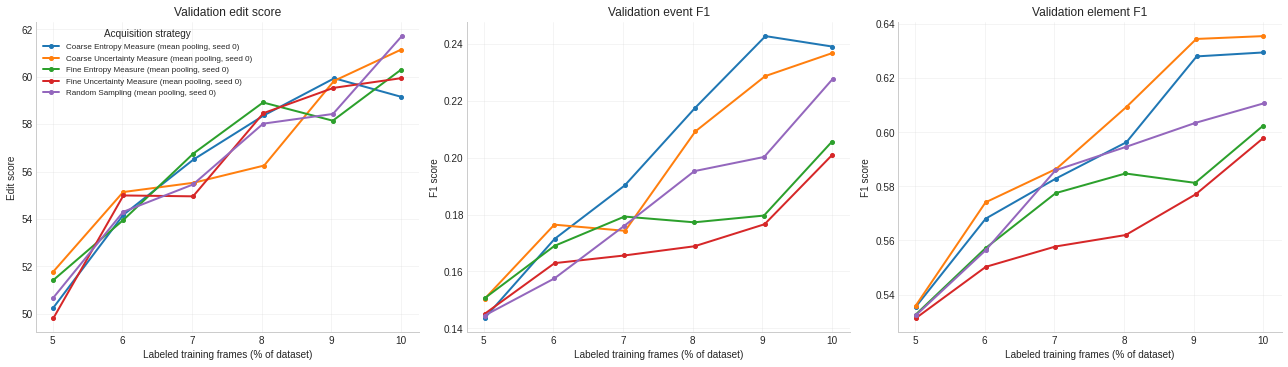

In [2]:
plot_validation_metrics("labeled_budget_pct");

## Performance vs. Acquisition Unit (No. of clips)

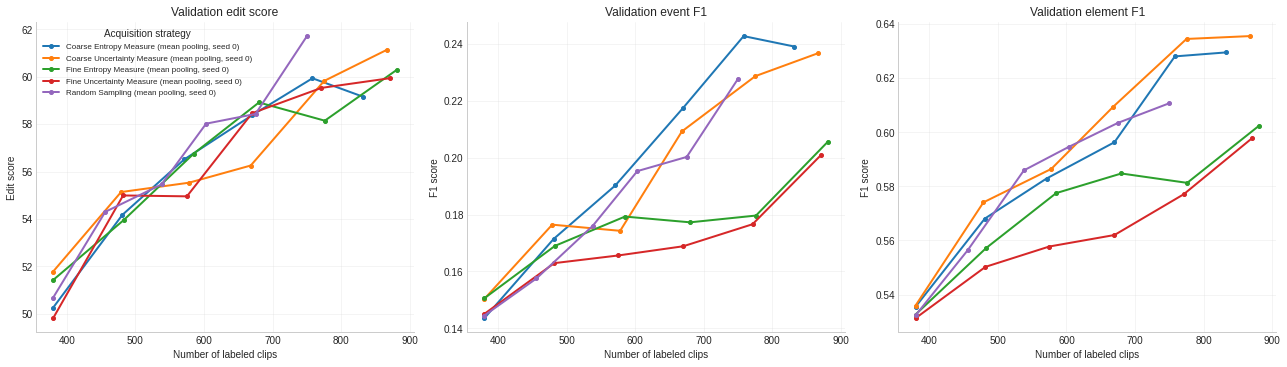

In [3]:
plot_validation_metrics("labeled_clips");

## Query Scores

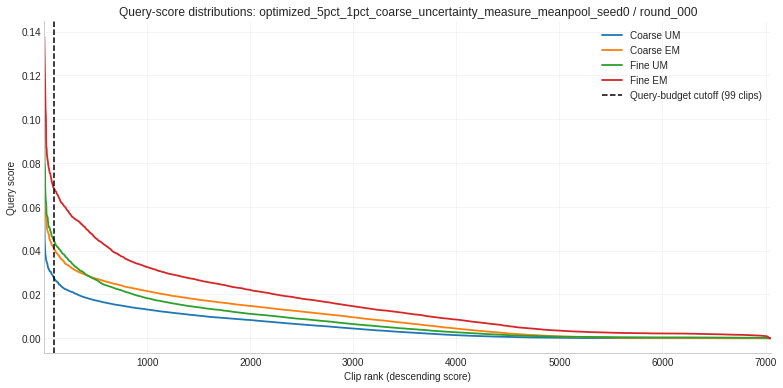

In [4]:
query_round_dir = (
    experiment_dir
    / "optimized_5pct_1pct_coarse_uncertainty_measure_meanpool_seed0"
    / "round_000"
)
with (query_round_dir / "query_scores.json").open() as file:
    query_score_records = json.load(file)

query_scores_df = pd.DataFrame.from_records(query_score_records)
score_labels = {
    "coarse_uncertainty_measure": "Coarse UM",
    "coarse_entropy_measure": "Coarse EM",
    "fine_uncertainty_measure": "Fine UM",
    "fine_entropy_measure": "Fine EM",
}
missing_columns = set(score_labels) - set(query_scores_df.columns)
if missing_columns:
    raise ValueError(f"Missing query-score columns: {sorted(missing_columns)}")
if "selected" not in query_scores_df:
    raise ValueError("query_scores.json does not contain the selection metadata")

query_budget_clips = int(query_scores_df["selected"].sum())
if query_budget_clips <= 0:
    raise ValueError("No clips are marked as selected; cannot locate the query-budget cutoff")

fig, ax = plt.subplots(figsize=(11, 5.5))
clip_ranks = range(1, len(query_scores_df) + 1)
for score_column, label in score_labels.items():
    sorted_scores = query_scores_df[score_column].sort_values(ascending=False).to_numpy()
    ax.plot(clip_ranks, sorted_scores, linewidth=1.8, label=label)

# Put the line between the last queried clip and the rest of the pool.
ax.axvline(
    query_budget_clips + 0.5,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Query-budget cutoff ({query_budget_clips} clips)",
)
ax.set(
    title=f"Query-score distributions: {query_round_dir.parent.name} / {query_round_dir.name}",
    xlabel="Clip rank (descending score)",
    ylabel="Query score",
)
ax.set_xlim(1, len(query_scores_df))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

In [5]:
query_scores_df
query_scores_df.sort_values(by="coarse_uncertainty_measure", ascending=False)

,index,video,selected,coarse_uncertainty_measure,fine_uncertainty_measure,coarse_entropy_measure,fine_entropy_measure
2134,2240,20230128-W-Australian_Open-F-Aryna_Sabalenka-E...,True,0.054601,0.004052,0.058582,0.011531
2033,2135,20150607-M-Roland_Garros-F-Stan_Wawrinka-Novak...,True,0.054252,0.004736,0.087439,0.018966
6656,7013,20150603-M-Roland_Garros-QF-Novak_Djokovic-Raf...,True,0.048923,0.016554,0.066202,0.033248
5716,6025,20200130-M-Australian_Open-SF-Roger_Federer-No...,True,0.048570,0.000500,0.064059,0.002761
4051,4270,20220126-M-Australian_Open-QF-Stefanos_Tsitsip...,True,0.043929,0.008347,0.067575,0.017541
...,...,...,...,...,...,...,...
2452,2577,20140706-M-Wimbledon-F-Novak_Djokovic-Roger_Fe...,False,0.000000,0.003022,0.000031,0.011406
2453,2578,20200128-W-Australian_Open-QF-Ashleigh_Barty-P...,False,0.000000,0.000543,0.000017,0.003076
2467,2593,20200201-W-Australian_Open-F-Sofia_Kenin-Garbi...,False,0.000000,0.000158,0.000029,0.000982
5631,5933,20220907-W-US_Open-QF-Karolina_Pliskova-Aryna_...,False,0.000000,0.016689,0.000029,0.023849
